  0%|          | 0/5 [00:00<?, ?it/s]

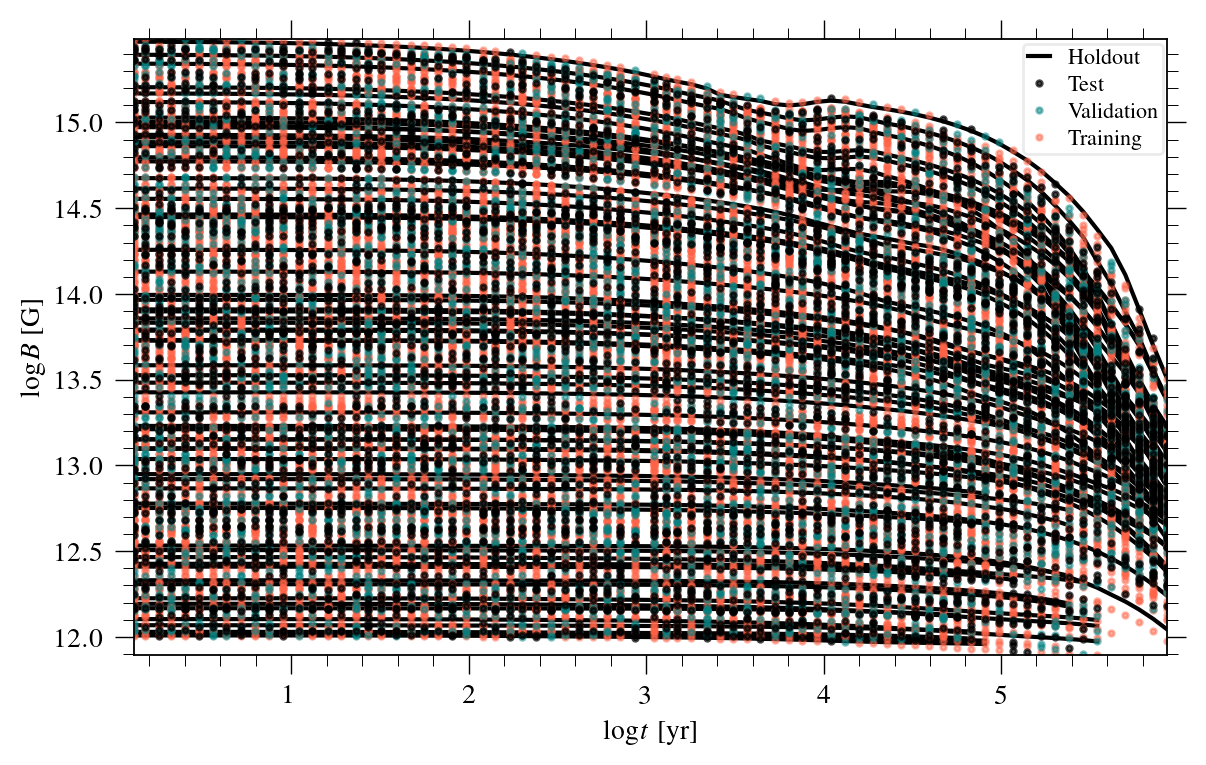

In [84]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


plt.style.use('./astrostyle.mplstyle')


DATASET_TYPES = ["train", "valid", "test", "holdout"]
DATASET_COLORS = ["tomato", "teal", "black", "black"]
DATASET_LABELS = ["Training", "Validation", "Test", "Holdout"]
ZORDER_BY_TYPE = {"train": 1, "valid": 2, "test": 3, "holdout": 0}

COLOR_BY_TYPE = {typ: col for typ, col in zip(DATASET_TYPES, DATASET_COLORS)}
LABEL_BY_TYPE = {typ: lbl for typ, lbl in zip(DATASET_TYPES, DATASET_LABELS)}
ALPHA_BY_TYPE = {"train": 0.5, "valid": 0.5, "test": 0.7, "holdout":1}


def read_datasets(folder):
    filepaths = glob.glob(os.path.join(folder, "**", "*.csv*"), recursive=True)
    data = {}
    for filepath in tqdm(filepaths):
        for key in DATASET_TYPES:
            if key in filepath:
                assert key not in data
                data[key] = pd.read_csv(filepath, index_col="index")
    return data


def make_dataset_plot(savepath=None):
    x_col = "logt"
    y_col = "logB"

    # get the figure size from the style and double it for better visibility
    style_figsize = plt.rcParams['figure.figsize']
    plt.figure(figsize=(style_figsize[0] * 2, style_figsize[1] * 2))
    for key, dataset in data.items():
        color = COLOR_BY_TYPE[key]
        label = LABEL_BY_TYPE[key]
        alpha = ALPHA_BY_TYPE[key]
        border = BORDER_BY_TYPE[key]
        zorder = ZORDER_BY_TYPE[key]

        if key == "holdout":
            plt.plot([], [], "-", color=color, alpha=alpha, label=label)
            indices = set(dataset.index)
            for index in indices:
                system = dataset.loc[index]
                plt.plot(system[x_col], system[y_col], "-", color=color, alpha=alpha, zorder=zorder)
        else:
            plt.plot(dataset[x_col], dataset[y_col], "o", mfc=color, markersize=2, color=color, alpha=alpha, zorder=zorder, label=label)
    plt.xlabel("$\log t$ [yr]")
    plt.ylabel("$\log B$ [G]")
    plt.legend()
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()


data = read_datasets("../../data/datasets")
make_dataset_plot(savepath="../../figures/datasets_plot.pdf")